In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [ ]:
import pandas as pd
df = pd.read_csv('tourism.csv')
display(df.head())


,ds,Region,State,Purpose,y
0,1998-01-01,Adelaide,South Australia,Business,135.077690
1,1998-04-01,Adelaide,South Australia,Business,109.987316
2,1998-07-01,Adelaide,South Australia,Business,166.034687
3,1998-10-01,Adelaide,South Australia,Business,127.160464
4,1999-01-01,Adelaide,South Australia,Business,137.448533


In [ ]:
df[ 'ds'] = pd.to_datetime(df['ds'])
df = df[(df["Region"] == "Sydney") & (df["Purpose"] == "Holiday")]
df = df.sort_values("ds")
display(df.head())

,ds,Region,State,Purpose,y
21520,1998-01-01,Sydney,New South Wales,Holiday,828.317118
21521,1998-04-01,Sydney,New South Wales,Holiday,531.434192
21522,1998-07-01,Sydney,New South Wales,Holiday,502.870983
21523,1998-10-01,Sydney,New South Wales,Holiday,579.748044
21524,1999-01-01,Sydney,New South Wales,Holiday,465.497480


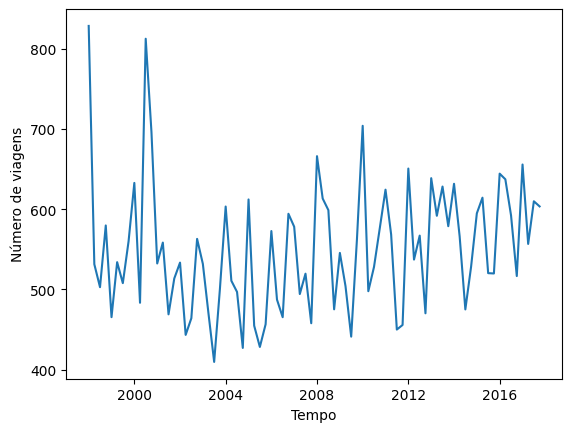

In [ ]:
plt.figure()
plt.plot(df['ds'], df['y'])
plt.xlabel("Tempo")
plt.ylabel("Número de viagens")
plt.show()

A série apresenta variações ao longo do tempo, com valores entre aproximadamente 400 e 830. Em relação à tendência, não há um crescimento ou queda fortemente definida em todo o intervalo. Quanto a sazonalidade, a série aparenta apresentar oscilações recorrentes, com picos e vales que se repetem ao longo dos anos. Apresenta alta variabilidade, alguns picos mais acentuados (como no início da série) podem indicar eventos atípicos ou variações específicas daquele período.

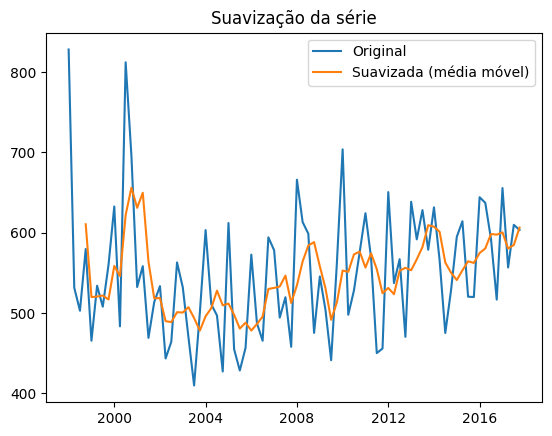

In [ ]:
df['media_movel'] = df['y'].rolling(window=4).mean()

plt.figure()
plt.plot(df['ds'], df['y'], label="Original")
plt.plot(df['ds'], df['media_movel'], label="Suavizada (média móvel)")
plt.legend()
plt.title("Suavização da série")
plt.show()

Para melhor visualizar o comportamento da série ao longo do tempo, foi aplicada uma média móvel, que reduz o ruído das oscilações de curto prazo e evidencia padrões mais estruturais. A suavização também evidencia que, apesar da alta variabilidade da série original, o nível médio permaneceu relativamente estável na segunda metade do período, sem tendência clara de crescimento ou declínio acentuado.

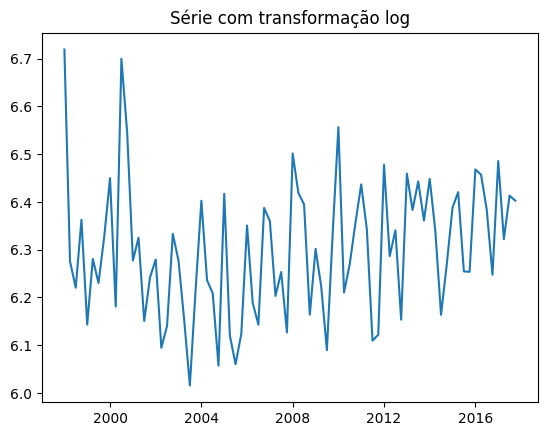

In [ ]:
df['log_y'] = np.log(df['y'])
plt.figure()
plt.plot(df['ds'], df['log_y'])
plt.title("Série com transformação log")
plt.show()

Para estabilizar a variância da série, foi aplicada a transformação logarítmica. Após a transformação, os valores passam a oscilar em uma faixa mais estreita (entre 6,0 e 6,7). O padrão geral da série se mantém: as oscilações recorrentes (sazonalidade) continuam visíveis, e a ausência de tendência clara também é preservada.

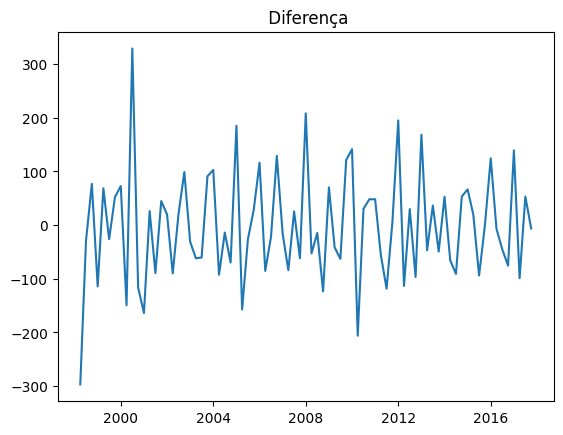

In [ ]:
df['diff1'] = df['y'].diff()
plt.figure()
plt.plot(df['ds'], df['diff1'])
plt.title(" Diferença")
plt.show()

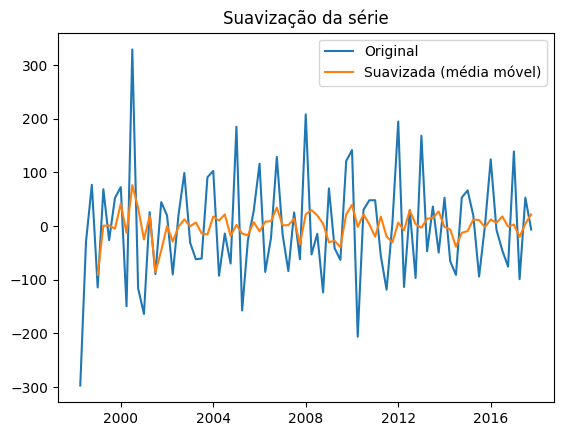

In [ ]:
df['media_movel'] = df['diff1'].rolling(window=4).mean()

plt.figure()
plt.plot(df['ds'], df['diff1'], label="Original")
plt.plot(df['ds'], df['media_movel'], label="Suavizada (média móvel)")
plt.legend()
plt.title("Suavização da série")
plt.show()

Para remover a tendência e buscar a estacionariedade da série, foi aplicada a diferenciação de primeira ordem. A série diferenciada passa a oscilar em torno de zero, sem nível crescente ou decrescente evidente, o que indica que a diferenciação foi eficaz em eliminar componentes não estacionários.
A média móvel aplicada sobre a série diferenciada reforça essa observação: a curva suavizada mantém-se próxima de zero ao longo de todo o período, confirmando a ausência de tendência.

In [ ]:
def grafico_sazonalidade(x, s):
    x = np.asarray(x, dtype=float)
    N = len(x)
    Mx = np.nanmax(x)
    mx = np.nanmin(x)
    valor = N // s
    eixox = np.arange(1, s + 1)

    plt.figure()
    for i in range(1, valor + 1):
        y = x[(i-1)*s : i*s]
        plt.plot(eixox, y, color=f"C{i}")

    # Último segmento residual
    restante = x[valor*s : N]
    if len(restante) > 0:
        plt.plot(np.arange(1, len(restante) + 1), restante, color=f"C{valor+1}")

    plt.ylim(mx, Mx)
    plt.xlim(0, s + 1)
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.title("Gráfico de Sazonalidade")
    plt.tight_layout()
    plt.show()


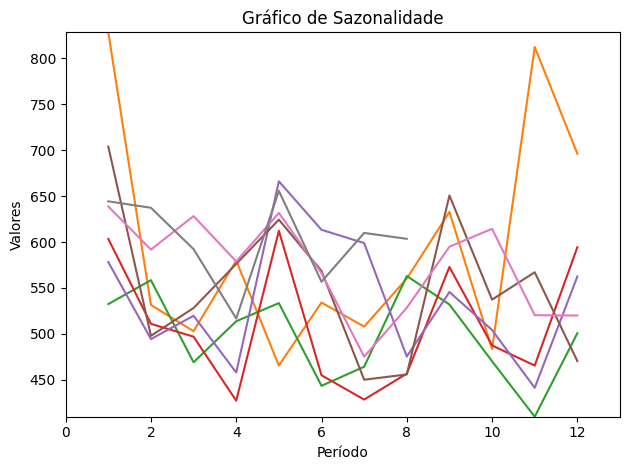

In [ ]:
grafico_sazonalidade(df["y"],12)

O gráfico de sazonalidade apresenta o comportamento da série ao longo dos 12 períodos (meses) para cada ano, permitindo identificar padrões que se repetem. Apesar de as linhas de diferentes anos não seguirem um padrão perfeitamente uniforme, o comportamento oscilatório recorrente reforça a presença de sazonalidade na série.